# Fig. 5 and S5: bridging unpaired RNA and ATAC cohorts

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/reproducibility/api/fig5_bridge.ipynb)

This notebook follows the bridge analysis in the Genome Research article more closely:

1. train UniVI **only** on the paired, unlabeled 10x Multiome reference;
2. project Ding et al. RNA-only and Satpathy et al. ATAC-only cohorts into the frozen reference latent;
3. evaluate the joint pre-refinement latent across **all four dataset/modality blocks**;
4. use harmonized labels from the *external Ding/Satpathy cohorts* for optional supervised refinement while keeping the decoders frozen;
5. recompute the joint latent across all four blocks after refinement;
6. transfer the refined classifier predictions **back onto the unlabeled Multiome reference**;
7. validate those Multiome predictions with RNA marker expression.

The paper-like refinement uses the harmonized coarse query labels. A second **head-only higher-resolution classifier** is then trained on the refined latent using the finer harmonized query labels, so the Multiome can also receive the more detailed annotations without using its previously exported predictions as supervision.

Settings follow the archived notebook `UniVI_manuscript_GR-Figure__5__Multiome_bridge_mapping_and_fine-tuning.ipynb`; preprocessing uses UniVI's fitted public-API preprocessors, so exact numeric values may differ slightly from the archived v0.4.7 analysis.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.1"

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

import univi.datasets as uds
from univi import (
    ClassHeadConfig,
    ModalityConfig,
    RefinementConfig,
    TrainingConfig,
    UniVIConfig,
    UniVIMultiModalVAE,
    UniVIRefiner,
    UniVITrainer,
    predict_heads_adata,
)
from univi.evaluation import encode_adata, encode_fused_adata_pair
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor
from univi.utils.seed import set_seed
from univi.workflows import make_loader, stack_embeddings

device = (
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
set_seed(0)
print("device:", device)

device: cuda


C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 5000
REFINE_EPOCHS = 3000
HIGHRES_HEAD_EPOCHS = 300

N_HVG = 2000
N_LSI = 100

# Paper-like semantic refinement.
COARSE_LABEL_KEY = "bridge_label_coarse"
COARSE_HEAD_KEY = "bridge_celltype_coarse"

# Finer annotation head trained only AFTER coarse refinement.
HIGHRES_LABEL_KEY = "bridge_label_highres"
HIGHRES_HEAD_KEY = "bridge_celltype_highres"

MULTIOME_COARSE_PRED = "predicted_celltype_coarse"
MULTIOME_HIGHRES_PRED = "predicted_celltype_highres"
MULTIOME_HIGHRES_CONF = "predicted_celltype_highres_confidence"

# These are source/query catch-all labels rather than useful biological
# classes for the detailed prediction head.
HIGHRES_EXCLUDE = {"Unknown", "Unassigned", "General PBMC", "Megakaryocyte",}
COARSE_EXCLUDE = {"Unknown", "Unassigned", "General PBMC", "Other",}

## Data and label provenance

`rna` and `atac` are the paired Multiome bridge reference. They are treated as **unlabeled for refinement**.

`ding_rna` and `satpathy_atac` are the labeled external RNA-only and ATAC-only cohorts. Their harmonized labels provide the optional supervision used after zero-shot projection.

The hosted Multiome objects may contain archived prediction columns from the manuscript preparation workflow. Those columns are retained for provenance/optional comparison only; they are **never used as training labels below**.

In [4]:
data = uds.load("pbmc_multiome_bridge")
rna, atac, ding, sat = data["rna"], data["atac"], data["ding_rna"], data["satpathy_atac"]

In [5]:
# ------------------------------------------------------------
# Query labels only.
# The Multiome reference is intentionally NOT assigned a
# training label here.
# ------------------------------------------------------------
def copy_first_available_label(adata, candidates, out_key, name):
    for key in candidates:
        if key in adata.obs.columns:
            adata.obs[out_key] = adata.obs[key].astype(str)
            print(
                f"{name}: {out_key!r} <- {key!r} "
                f"({adata.obs[out_key].nunique()} classes)"
            )
            return key

    raise KeyError(
        f"{name}: none of {candidates} found.\n"
        f"Available obs columns:\n{list(adata.obs.columns)}"
    )

ding_coarse_source = copy_first_available_label(
    ding,
    ["celltype_harmonized_coarse", "release_celltype_coarse"],
    COARSE_LABEL_KEY,
    "Ding RNA",
)
sat_coarse_source = copy_first_available_label(
    sat,
    ["celltype_harmonized_coarse", "release_celltype_coarse"],
    COARSE_LABEL_KEY,
    "Satpathy ATAC",
)

ding_highres_source = copy_first_available_label(
    ding,
    ["celltype_harmonized", "celltype_raw", "celltype"],
    HIGHRES_LABEL_KEY,
    "Ding RNA",
)
sat_highres_source = copy_first_available_label(
    sat,
    ["celltype_harmonized", "celltype_raw", "celltype"],
    HIGHRES_LABEL_KEY,
    "Satpathy ATAC",
)

print("\nSupervision provenance:")
print("  Multiome reference : unlabeled / no supervision")
print("  Ding coarse        :", ding_coarse_source)
print("  Satpathy coarse    :", sat_coarse_source)
print("  Ding high-res      :", ding_highres_source)
print("  Satpathy high-res  :", sat_highres_source)

# Existing hosted predictions are useful only as an optional
# reproducibility check after we generate new predictions.
archived_pred_key = (
    "celltype_higher_res_pred"
    if "celltype_higher_res_pred" in rna.obs.columns
    else None
)
print("  archived Multiome prediction column:", archived_pred_key)

Ding RNA: 'bridge_label_coarse' <- 'celltype_harmonized_coarse' (8 classes)
Satpathy ATAC: 'bridge_label_coarse' <- 'celltype_harmonized_coarse' (7 classes)
Ding RNA: 'bridge_label_highres' <- 'celltype_harmonized' (10 classes)
Satpathy ATAC: 'bridge_label_highres' <- 'celltype_harmonized' (12 classes)

Supervision provenance:
  Multiome reference : unlabeled / no supervision
  Ding coarse        : celltype_harmonized_coarse
  Satpathy coarse    : celltype_harmonized_coarse
  Ding high-res      : celltype_harmonized
  Satpathy high-res  : celltype_harmonized
  archived Multiome prediction column: celltype_higher_res_pred


In [6]:
genes = rna.var_names.intersection(ding.var_names)
peaks = atac.var_names.intersection(sat.var_names)

rna = rna[:, genes].copy()
atac = atac[:, peaks].copy()

print(
    f"shared genes {len(genes)}, shared peaks {len(peaks)}; "
    f"reference {rna.n_obs}, Ding {ding.n_obs}, Satpathy {sat.n_obs}"
)

if "split" in rna.obs:
    splits = {
        k: np.flatnonzero(rna.obs["split"].to_numpy() == k)
        for k in ("train", "val")
    }
else:
    # Archived notebook: random 90/10, seed 42.
    idx = np.random.default_rng(42).permutation(rna.n_obs)
    cut = int(0.9 * len(idx))
    splits = {
        "train": np.sort(idx[:cut]),
        "val": np.sort(idx[cut:]),
    }

rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True,).fit(rna[splits["train"]])
atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=False, scale=True,).fit(atac[splits["train"]])
ref = {"rna": rna_prep.transform(rna), "atac": atac_prep.transform(atac),}

# Materialized copies avoid AnnData-view expansion during row-wise loading.
train = {
    m: a[splits["train"]].copy()
    for m, a in ref.items()
}
val = {
    m: a[splits["val"]].copy()
    for m, a in ref.items()
}

ding_pp = rna_prep.transform(ding[:, genes])
sat_pp = atac_prep.transform(sat[:, peaks])

print("reference RNA :", ref["rna"].shape)
print("reference ATAC:", ref["atac"].shape)
print("Ding RNA      :", ding_pp.shape)
print("Satpathy ATAC :", sat_pp.shape)

shared genes 9022, shared peaks 85485; reference 12012, Ding 30495, Satpathy 47148
reference RNA : (12012, 2000)
reference ATAC: (12012, 100)
Ding RNA      : (30495, 2000)
Satpathy ATAC : (47148, 100)


## Train the reference

In [7]:
cfg = UniVIConfig(
    latent_dim=30,
    beta=1.0,
    gamma=5.0,
    encoder_dropout=0.25,
    decoder_dropout=0.05,
    kl_anneal_start=0,
    kl_anneal_end=25,
    align_anneal_start=15,
    align_anneal_end=40,
    modalities=[
        ModalityConfig(
            "rna",
            train["rna"].n_vars,
            [512, 256, 128],
            [128, 256, 512],
            likelihood="gaussian",
        ),
        ModalityConfig(
            "atac",
            train["atac"].n_vars,
            [128, 64],
            [64, 128],
            likelihood="gaussian",
        ),
    ],
)

model = UniVIMultiModalVAE(
    cfg,
    loss_mode="v1",
    v1_recon="avg",
    normalize_v1_terms=True,
)

base_trainer = UniVITrainer(
    model,
    make_loader(
        train,
        batch_size=256,
        shuffle=True,
        drop_last=True,
    ),
    make_loader(
        val,
        batch_size=1024,
    ),
    TrainingConfig(
        n_epochs=N_EPOCHS,
        batch_size=256,
        lr=1e-3,
        weight_decay=1e-4,
        device=device,
        early_stopping=True,
        patience=150,
        best_epoch_warmup=40,
        log_every=100,
    ),
)

_base_result = base_trainer.fit()
print("Base Multiome reference training complete.")

[2026-09-21 19:33:10,184] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-21 19:33:10,185] [UniVITrainer] [INFO]   n_epochs: 5000
[2026-09-21 19:33:10,185] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-21 19:33:10,186] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-21 19:33:10,186] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-21 19:33:10,186] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-21 19:33:10,187] [UniVITrainer] [INFO]   log_every: 100
[2026-09-21 19:33:10,187] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-21 19:33:10,188] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-21 19:33:10,188] [UniVITrainer] [INFO]   seed: 0
[2026-09-21 19:33:10,188] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-21 19:33:10,189] [UniVITrainer] [INFO]   patience: 150
[2026-09-21 19:33:10,189] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-21 19:33:10,189] [UniVITrainer] [INFO]   best_epoch_warmup: 40
Training UniVI:   0%|          | 0/5000 [00:00<?, ?it/s][2026-09-21 19:33:11,482] [

Base Multiome reference training complete.


## Parameter-frozen bridge projection: all data before refinement

The trained Multiome generative model is now held fixed while Ding RNA and Satpathy ATAC are projected through the corresponding encoders.

As in Fig. 5A–C, the visualization contains **all four blocks**: Multiome RNA, Multiome ATAC, Ding RNA, and Satpathy ATAC.

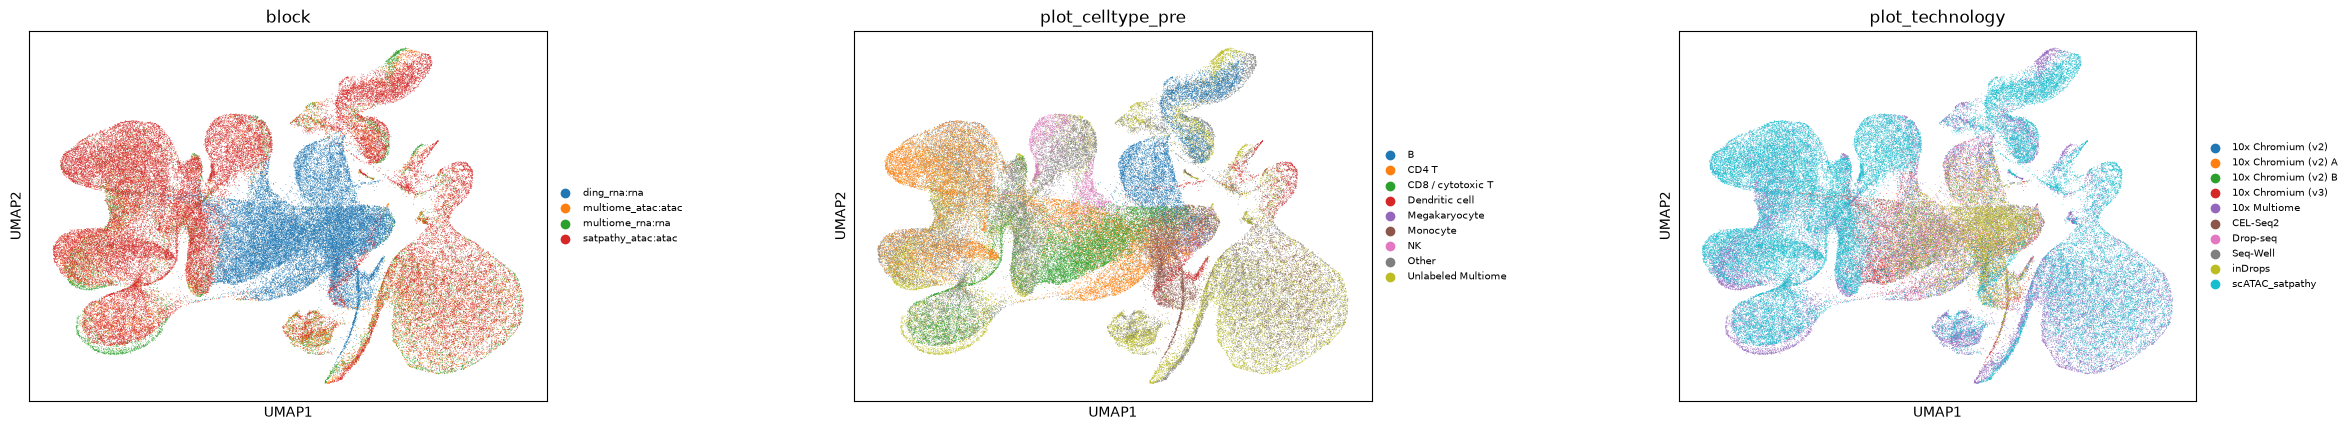

In [8]:
def technology_values(adata, fallback):
    candidates = [
        "technology",
        "platform",
        "method",
        "tech",
        "assay",
        "library_protocol",
    ]
    for key in candidates:
        if key in adata.obs.columns:
            return adata.obs[key].astype(str).to_numpy()
    return np.repeat(fallback, adata.n_obs)

# Multiome is unlabeled before classifier transfer.
for a in ref.values():
    a.obs["plot_celltype_pre"] = "Unlabeled Multiome"
    a.obs["plot_technology"] = "10x Multiome"

ding_pp.obs["plot_celltype_pre"] = ding_pp.obs[COARSE_LABEL_KEY].astype(str)
sat_pp.obs["plot_celltype_pre"] = sat_pp.obs[COARSE_LABEL_KEY].astype(str)

ding_pp.obs["plot_technology"] = technology_values(ding_pp, "Ding RNA")
sat_pp.obs["plot_technology"] = technology_values(sat_pp, "Satpathy ATAC")

bridge_blocks = [
    ("multiome_rna", "rna", ref["rna"]),
    ("multiome_atac", "atac", ref["atac"]),
    ("ding_rna", "rna", ding_pp),
    ("satpathy_atac", "atac", sat_pp),
]

joint_pre = stack_embeddings(model, bridge_blocks, device=device,)

sc.pp.neighbors(
    joint_pre,
    use_rep="X_univi",
    n_neighbors=30,
)
sc.tl.umap(
    joint_pre,
    random_state=0,
)
sc.pl.umap(
    joint_pre,
    color=[
        "block",
        "plot_celltype_pre",
        "plot_technology",
    ],
    wspace=0.45,
    legend_fontsize=7,
)

## Cross-cohort label transfer before refinement

Fig. 5G evaluates **Ding ↔ Satpathy**, not Multiome ↔ query. Multiome has no curated ground-truth cell labels.

The transfer metric therefore uses the harmonized coarse labels available in both external cohorts. The higher-resolution labels are reserved for the detailed prediction head applied to Multiome later.

In [9]:
def valid_labeled(adata, key, excluded):
    y = adata.obs[key].astype(str)
    return ~y.isin(excluded)

def directional_knn(
    z_source,
    y_source,
    z_target,
    y_target,
    n_neighbors=15,
):
    y_source = np.asarray(y_source, dtype=str)
    y_target = np.asarray(y_target, dtype=str)
    shared = sorted(set(y_source) & set(y_target))
    source_mask = np.isin(y_source, shared)
    target_mask = np.isin(y_target, shared)
    clf = KNeighborsClassifier(n_neighbors=n_neighbors,).fit(z_source[source_mask], y_source[source_mask],)
    pred = clf.predict(z_target[target_mask])
    truth = y_target[target_mask]
    
    return {
        "labels": shared,
        "truth": truth,
        "pred": pred,
        "accuracy": accuracy_score(truth, pred),
        "macro_f1": f1_score(
            truth,
            pred,
            labels=shared,
            average="macro",
            zero_division=0,
        ),
        "confusion": confusion_matrix(
            truth,
            pred,
            labels=shared,
            normalize="true",
        ),
    }

def bidirectional_transfer(model):
    z_ding = encode_adata(
        model,
        ding_pp,
        modality="rna",
        device=device,
        latent="modality_mean",
    )
    z_sat = encode_adata(
        model,
        sat_pp,
        modality="atac",
        device=device,
        latent="modality_mean",
    )
    dmask = valid_labeled(ding_pp, COARSE_LABEL_KEY, COARSE_EXCLUDE,).to_numpy()
    smask = valid_labeled(sat_pp, COARSE_LABEL_KEY, COARSE_EXCLUDE,).to_numpy()
    y_ding = (ding_pp.obs.loc[dmask, COARSE_LABEL_KEY].astype(str).to_numpy())
    y_sat = (sat_pp.obs.loc[smask, COARSE_LABEL_KEY].astype(str).to_numpy())

    return {
        "Ding RNA → Satpathy ATAC": directional_knn(
            z_ding[dmask],
            y_ding,
            z_sat[smask],
            y_sat,
            n_neighbors=15,
        ),
        "Satpathy ATAC → Ding RNA": directional_knn(
            z_sat[smask],
            y_sat,
            z_ding[dmask],
            y_ding,
            n_neighbors=15,
        ),
    }

pre_transfer = bidirectional_transfer(model)

for direction, result in pre_transfer.items():
    print(
        f"{direction}: "
        f"accuracy={result['accuracy']:.3f}, "
        f"macro-F1={result['macro_f1']:.3f}"
    )

Ding RNA → Satpathy ATAC: accuracy=0.820, macro-F1=0.761
Satpathy ATAC → Ding RNA: accuracy=0.327, macro-F1=0.386


## Optional supervised refinement from the labeled projected cohorts

This follows the paper's information flow:

- **Ding RNA + Satpathy ATAC provide supervision**.
- **Multiome provides no cell-type supervision**.
- the classifier head is warmed up first;
- the modality encoders are then allowed to adapt at a smaller learning rate;
- the generative decoders remain frozen.

The coarse harmonized vocabulary drives the latent refinement so the cross-cohort comparison remains meaningful. A separate head-only higher-resolution classifier is fit afterward for more detailed Multiome annotation.

In [10]:
def supervised_split(
    adata,
    label_key,
    excluded,
    seed,
    val_fraction=0.10,
):
    labels = adata.obs[label_key].astype(str)
    keep = ~labels.isin(excluded)
    clean = adata[keep.to_numpy()].copy()
    idx = np.arange(clean.n_obs)
    y = clean.obs[label_key].astype(str).to_numpy()
    train_idx, val_idx = train_test_split(
        idx,
        test_size=val_fraction,
        random_state=seed,
        stratify=y,
    )
    
    return (
        clean[train_idx].copy(),
        clean[val_idx].copy(),
    )

# ------------------------------------------------------------
# Train / validation splits from the LABELED external cohorts.
# Multiome remains unlabeled and is NOT used as supervision.
# ------------------------------------------------------------
ding_coarse_train, ding_coarse_val = supervised_split(ding_pp, COARSE_LABEL_KEY, COARSE_EXCLUDE, seed=41,)
sat_coarse_train, sat_coarse_val = supervised_split(sat_pp, COARSE_LABEL_KEY, COARSE_EXCLUDE, seed=42,)

# ------------------------------------------------------------
# Shared coarse label vocabulary
# ------------------------------------------------------------
coarse_classes = sorted(set(ding_coarse_train.obs[COARSE_LABEL_KEY].astype(str)) | set(sat_coarse_train.obs[COARSE_LABEL_KEY].astype(str)))
coarse_code = {label: i for i, label in enumerate(coarse_classes)}
print(
    f"Coarse refinement vocabulary "
    f"({len(coarse_classes)} classes):"
)
print(coarse_classes)

# ------------------------------------------------------------
# Convert an .obs label column into UniVI head targets.
#
# IMPORTANT:
#   obs_key  = column containing the biological labels
#   head_key = name of the registered UniVI classification head
#
# UniVIRefiner requires the returned dictionary key to match
# model.class_heads exactly.
# ------------------------------------------------------------
def encoded_labels(
    adata,
    obs_key,
    head_key,
    code,
):
    values = (
        adata.obs[obs_key]
        .astype(str)
        .map(code)
        .to_numpy()
    )
    if pd.isna(values).any():
        missing = sorted(
            set(
                adata.obs.loc[
                    pd.isna(values),
                    obs_key,
                ].astype(str)
            )
        )
        raise ValueError(
            f"Unmapped labels found for {obs_key}: "
            f"{missing}"
        )

    return {
        head_key: values.astype(np.int64)
    }

# ------------------------------------------------------------
# Add classifier head
# ------------------------------------------------------------
model.add_classification_head(
    ClassHeadConfig(
        COARSE_HEAD_KEY,
        n_classes=len(coarse_classes),
        hidden_dims=[64, 64, 32],
        dropout=0.1,
        batchnorm=False,
        layernorm=True,
    ),
    label_names=coarse_classes,
)
print(
    f"Registered classification head: "
    f"{COARSE_HEAD_KEY!r}"
)
assert COARSE_HEAD_KEY in model.class_heads

# ------------------------------------------------------------
# Build refinement loaders
# ------------------------------------------------------------
coarse_refiner = UniVIRefiner(
    model,
    [
        make_loader(
            {"rna": ding_coarse_train},
            labels=encoded_labels(
                ding_coarse_train,
                COARSE_LABEL_KEY,
                COARSE_HEAD_KEY,
                coarse_code,
            ),
            batch_size=256,
            shuffle=True,
        ),
        make_loader(
            {"atac": sat_coarse_train},
            labels=encoded_labels(
                sat_coarse_train,
                COARSE_LABEL_KEY,
                COARSE_HEAD_KEY,
                coarse_code,
            ),
            batch_size=256,
            shuffle=True,
        ),
    ],
    [
        make_loader(
            {"rna": ding_coarse_val},
            labels=encoded_labels(
                ding_coarse_val,
                COARSE_LABEL_KEY,
                COARSE_HEAD_KEY,
                coarse_code,
            ),
            batch_size=1024,
        ),
        make_loader(
            {"atac": sat_coarse_val},
            labels=encoded_labels(
                sat_coarse_val,
                COARSE_LABEL_KEY,
                COARSE_HEAD_KEY,
                coarse_code,
            ),
            batch_size=1024,
        ),
    ],
    device=device,
    config=RefinementConfig(
        max_epochs=REFINE_EPOCHS,
        warmup_epochs=min(
            300,
            REFINE_EPOCHS,
        ),
        lr_head=3e-4,
        lr_encoder=1e-5,
        log_every=100,
    ),
)

# ------------------------------------------------------------
# Run refinement.
#
# Assigning the return value prevents Jupyter / ReadTheDocs from
# rendering the enormous {'history': [...]} dictionary.
# ------------------------------------------------------------
coarse_refinement_result = coarse_refiner.fit()

# Compact summary only
history = (
    coarse_refinement_result.get("history", [])
    if isinstance(coarse_refinement_result, dict)
    else []
)

if history:
    last = history[-1]
    val_loss = last.get(
        "val_supervised_loss",
        last.get("val_loss", np.nan),
    )
    print(
        "\nCoarse refinement complete:"
        f"\n  epochs: {len(history)}"
        f"\n  final stage: {last.get('stage', 'unknown')}"
        f"\n  final validation loss: {val_loss:.4f}"
    )
else:
    print("\nCoarse refinement complete.")
    

Coarse refinement vocabulary (7 classes):
['B', 'CD4 T', 'CD8 / cytotoxic T', 'Dendritic cell', 'Megakaryocyte', 'Monocyte', 'NK']
Registered classification head: 'bridge_celltype_coarse'
Refinement 0: heads, validation=0.66662
Refinement 100: heads, validation=0.28577
Refinement 200: heads, validation=0.28001
Refinement 300: encoders+heads, validation=0.34244
Refinement 400: encoders+heads, validation=0.19294
Refinement 500: encoders+heads, validation=0.19574

Coarse refinement complete:
  epochs: 509
  final stage: encoders+heads
  final validation loss: 0.1961


In [11]:
def _extract_x_dict(batch):
    if isinstance(batch, dict):
        # Most direct make_loader form.
        if all(
            torch.is_tensor(v)
            for v in batch.values()
        ):
            return batch
        for key in ("x", "x_dict", "inputs"):
            if (
                key in batch
                and isinstance(batch[key], dict)
            ):
                return batch[key]
    if isinstance(batch, (tuple, list)):
        for item in batch:
            if (
                isinstance(item, dict)
                and item
                and all(
                    torch.is_tensor(v)
                    for v in item.values()
                )
            ):
                return item
    raise TypeError(
        "Could not locate modality tensor dictionary "
        f"in batch of type {type(batch)}"
    )

def predict_paired_heads(
    model,
    adata_by_mod,
    device,
    batch_size=1024,
):
    loader = make_loader(
        adata_by_mod,
        batch_size=batch_size,
        shuffle=False,
    )
    chunks = {}
    model.eval()
    with torch.no_grad():
        for batch in loader:
            x_dict = _extract_x_dict(batch)
            x_dict = {
                key: value.to(device)
                for key, value in x_dict.items()
            }
            try:
                pred = model.predict_heads(
                    x_dict,
                    return_probs=True,
                )
            except TypeError:
                pred = model.predict_heads(
                    x_dict
                )
            for key, value in pred.items():
                if torch.is_tensor(value):
                    value = (
                        value.detach()
                        .cpu()
                        .numpy()
                    )
                chunks.setdefault(
                    key, []
                ).append(
                    np.asarray(value)
                )
    return {
        key: np.concatenate(value, axis=0)
        for key, value in chunks.items()
    }

# Apply the coarse refinement head to the PAIRED Multiome
# using both modalities through model.predict_heads().
paired_head_probs = predict_paired_heads(model, ref, device=device,)
coarse_probs = paired_head_probs[COARSE_HEAD_KEY]
coarse_pred = np.asarray(coarse_classes)[coarse_probs.argmax(axis=1)]

for a in ref.values():
    a.obs[MULTIOME_COARSE_PRED] = pd.Categorical(
        coarse_pred,
        categories=coarse_classes,
    )
print(
    "Coarse predictions written back to "
    f"{len(coarse_pred):,} paired Multiome cells."
)

Coarse predictions written back to 12,012 paired Multiome cells.


## Fine-tuned latent across all cohorts (Fig. 5D–F)

The embeddings are recomputed **after** supervised refinement for all four dataset/modality blocks.

For the semantic panel, Ding and Satpathy use their provided harmonized labels, while Multiome uses the classifier predictions transferred onto the previously unlabeled paired reference.

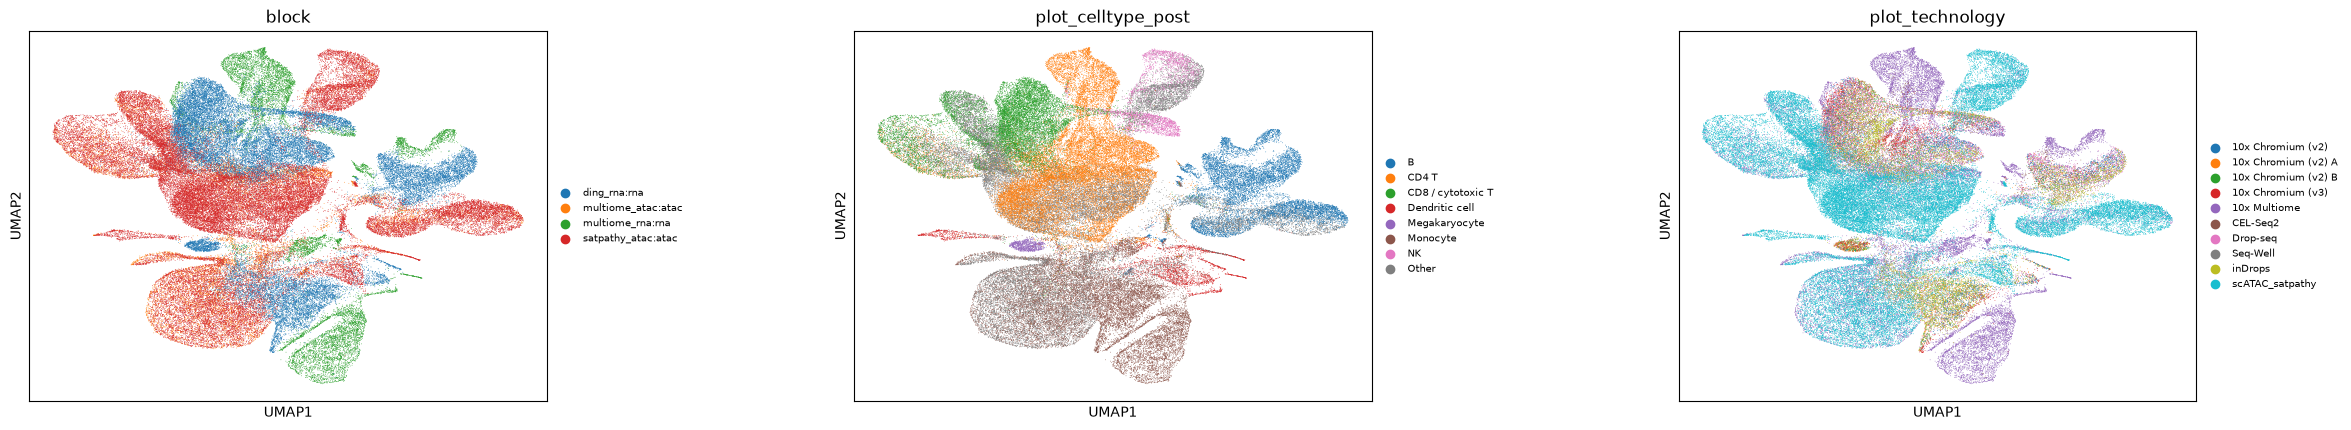

In [12]:
for a in ref.values():
    a.obs["plot_celltype_post"] = (
        a.obs[MULTIOME_COARSE_PRED]
        .astype(str)
    )

ding_pp.obs["plot_celltype_post"] = (ding_pp.obs[COARSE_LABEL_KEY].astype(str))
sat_pp.obs["plot_celltype_post"] = (sat_pp.obs[COARSE_LABEL_KEY].astype(str))

joint_post = stack_embeddings(model, bridge_blocks, device=device,)

sc.pp.neighbors(
    joint_post,
    use_rep="X_univi",
    n_neighbors=30,
)
sc.tl.umap(
    joint_post,
    random_state=0,
)

sc.pl.umap(
    joint_post,
    color=[
        "block",
        "plot_celltype_post",
        "plot_technology",
    ],
    wspace=0.45,
    legend_fontsize=7,
)

## Bidirectional label transfer after refinement (Fig. 5G)

The same Ding ↔ Satpathy k-NN test is rerun in the refined latent. Multiome remains excluded from this accuracy calculation because it has no curated ground truth.

Ding RNA → Satpathy ATAC: accuracy=0.883, macro-F1=0.832
Satpathy ATAC → Ding RNA: accuracy=0.835, macro-F1=0.784


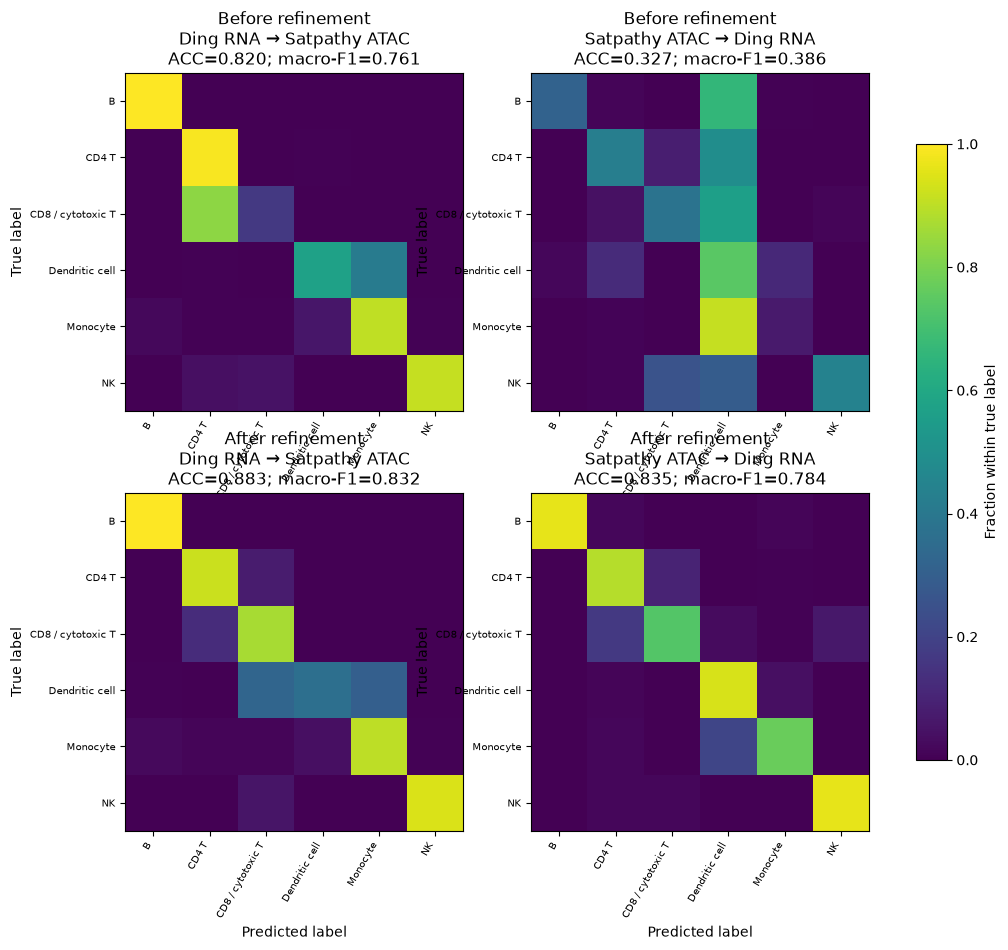

In [13]:
post_transfer = bidirectional_transfer(model)

for direction, result in post_transfer.items():
    print(
        f"{direction}: "
        f"accuracy={result['accuracy']:.3f}, "
        f"macro-F1={result['macro_f1']:.3f}"
    )

directions = [
    "Ding RNA → Satpathy ATAC",
    "Satpathy ATAC → Ding RNA",
]
stages = [
    ("Before refinement", pre_transfer),
    ("After refinement", post_transfer),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10),)

for row, (stage_name, results) in enumerate(stages):
    for col, direction in enumerate(directions):
        result = results[direction]
        ax = axes[row, col]
        image = ax.imshow(result["confusion"], vmin=0, vmax=1,)
        labels = result["labels"]
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(
            labels,
            rotation=60,
            ha="right",
            fontsize=7,
        )
        ax.set_yticklabels(
            labels,
            fontsize=7,
        )
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_title(
            f"{stage_name}\n{direction}\n"
            f"ACC={result['accuracy']:.3f}; "
            f"macro-F1={result['macro_f1']:.3f}"
        )

fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    label="Fraction within true label",
    shrink=0.8,
)
plt.show()

## Higher-resolution annotation head for the unlabeled Multiome reference

The paper's coarse head is what refines the latent geometry above.

To preserve the more detailed annotation used in the current hosted bridge data, we now attach a **second classifier head** using the finer harmonized Ding/Satpathy labels. This second stage is **head-only**: the already-refined encoders are kept fixed, so it does not alter the paper-like latent geometry.

Broad/noninformative source labels (`Unknown`, `Unassigned`, `General PBMC`) and the Ding-only megakaryocyte category are excluded, yielding the detailed immune vocabulary used for Multiome prediction.

In [16]:
ding_highres_train, ding_highres_val = supervised_split(
    ding_pp,
    HIGHRES_LABEL_KEY,
    HIGHRES_EXCLUDE,
    seed=51,
)
sat_highres_train, sat_highres_val = supervised_split(
    sat_pp,
    HIGHRES_LABEL_KEY,
    HIGHRES_EXCLUDE,
    seed=52,
)

# ------------------------------------------------------------
# Higher-resolution vocabulary from both labeled query cohorts
# ------------------------------------------------------------
highres_classes = sorted(
    set(
        ding_highres_train.obs[
            HIGHRES_LABEL_KEY
        ].astype(str)
    )
    | set(
        sat_highres_train.obs[
            HIGHRES_LABEL_KEY
        ].astype(str)
    )
)
highres_code = {
    label: i
    for i, label in enumerate(highres_classes)
}
print(
    f"High-resolution head vocabulary "
    f"({len(highres_classes)} classes):"
)
print(highres_classes)

# ------------------------------------------------------------
# Register the high-resolution head.
#
# Reuse it if this cell is rerun after a downstream error.
# ------------------------------------------------------------
if HIGHRES_HEAD_KEY not in model.class_heads:
    model.add_classification_head(
        ClassHeadConfig(
            HIGHRES_HEAD_KEY,
            n_classes=len(highres_classes),
            hidden_dims=[64, 64, 32],
            dropout=0.1,
            batchnorm=False,
            layernorm=True,
        ),
        label_names=highres_classes,
    )
    print(
        f"Registered classification head: "
        f"{HIGHRES_HEAD_KEY!r}"
    )
else:
    print(
        f"Classification head {HIGHRES_HEAD_KEY!r} "
        "already exists; reusing it."
    )
assert HIGHRES_HEAD_KEY in model.class_heads

# ------------------------------------------------------------
# Head-only high-resolution refinement
#
# IMPORTANT:
# encoded_labels() must return labels keyed by HIGHRES_HEAD_KEY,
# because that is the name registered in model.class_heads.
# ------------------------------------------------------------
highres_refiner = UniVIRefiner(
    model,
    [
        make_loader(
            {"rna": ding_highres_train},
            labels=encoded_labels(
                ding_highres_train,
                HIGHRES_LABEL_KEY,
                HIGHRES_HEAD_KEY,
                highres_code,
            ),
            batch_size=256,
            shuffle=True,
        ),
        make_loader(
            {"atac": sat_highres_train},
            labels=encoded_labels(
                sat_highres_train,
                HIGHRES_LABEL_KEY,
                HIGHRES_HEAD_KEY,
                highres_code,
            ),
            batch_size=256,
            shuffle=True,
        ),
    ],
    [
        make_loader(
            {"rna": ding_highres_val},
            labels=encoded_labels(
                ding_highres_val,
                HIGHRES_LABEL_KEY,
                HIGHRES_HEAD_KEY,
                highres_code,
            ),
            batch_size=1024,
        ),
        make_loader(
            {"atac": sat_highres_val},
            labels=encoded_labels(
                sat_highres_val,
                HIGHRES_LABEL_KEY,
                HIGHRES_HEAD_KEY,
                highres_code,
            ),
            batch_size=1024,
        ),
    ],
    device=device,
    config=RefinementConfig(
        max_epochs=HIGHRES_HEAD_EPOCHS,
        warmup_epochs=HIGHRES_HEAD_EPOCHS,
        lr_head=3e-4,
        lr_encoder=1e-5,
        log_every=100,
    ),
)

highres_refinement_result = highres_refiner.fit()
highres_history = (
    highres_refinement_result.get("history", [])
    if isinstance(highres_refinement_result, dict)
    else []
)

if highres_history:
    last = highres_history[-1]

    val_loss = last.get(
        "val_supervised_loss",
        last.get("val_loss", np.nan),
    )

    print(
        "\nHigh-resolution head training complete:"
        f"\n  epochs: {len(highres_history)}"
        f"\n  final stage: {last.get('stage', 'unknown')}"
        f"\n  final validation loss: {val_loss:.4f}"
    )
else:
    print("\nHigh-resolution head training complete.")

High-resolution head vocabulary (15 classes):
['B', 'CD14+ monocyte', 'CD16+ monocyte', 'CD4 T', 'CD4 T helper', 'Cytotoxic T', 'Dendritic cell', 'Memory CD4 T', 'Memory CD8 T', 'Monocyte', 'NK', 'Naive CD4 T', 'Naive CD8 T', 'Plasmacytoid dendritic cell', 'Regulatory T']
Classification head 'bridge_celltype_highres' already exists; reusing it.
Refinement 0: heads, validation=1.20436
Refinement 100: heads, validation=0.23246
Refinement 200: heads, validation=0.22903

High-resolution head training complete:
  epochs: 300
  final stage: heads
  final validation loss: 0.2290


## Transfer the refined predictions back onto Multiome (Fig. 5H–I; Supp. Fig. S5A–B)

Multiome was never used as a source of cell-type supervision.

Predictions are now made from the **paired fused Multiome representation** using both RNA and ATAC. The resulting label and confidence are copied onto both modality AnnData objects for plotting and downstream validation.

In [17]:
paired_head_probs = predict_paired_heads(
    model,
    ref,
    device=device,
)

highres_probs = paired_head_probs[
    HIGHRES_HEAD_KEY
]
highres_pred = np.asarray(
    highres_classes
)[highres_probs.argmax(axis=1)]
highres_conf = highres_probs.max(axis=1)

for a in ref.values():
    a.obs[MULTIOME_HIGHRES_PRED] = pd.Categorical(
        highres_pred,
        categories=highres_classes,
    )
    a.obs[MULTIOME_HIGHRES_CONF] = highres_conf
print(
    "Higher-resolution predictions written back to "
    f"{len(highres_pred):,} paired Multiome cells."
)

# Optional reproducibility comparison only. This is NOT a
# ground-truth accuracy metric and was not used for training.
if (
    archived_pred_key is not None
    and archived_pred_key in rna.obs.columns
):
    archived = rna.obs[
        archived_pred_key
    ].astype(str).to_numpy()
    archived_agreement = np.mean(
        highres_pred.astype(str)
        == archived
    )
    print(
        "Agreement with archived Multiome prediction column "
        f"({archived_pred_key}): "
        f"{archived_agreement:.3f}"
    )

Higher-resolution predictions written back to 12,012 paired Multiome cells.
Agreement with archived Multiome prediction column (celltype_higher_res_pred): 0.621


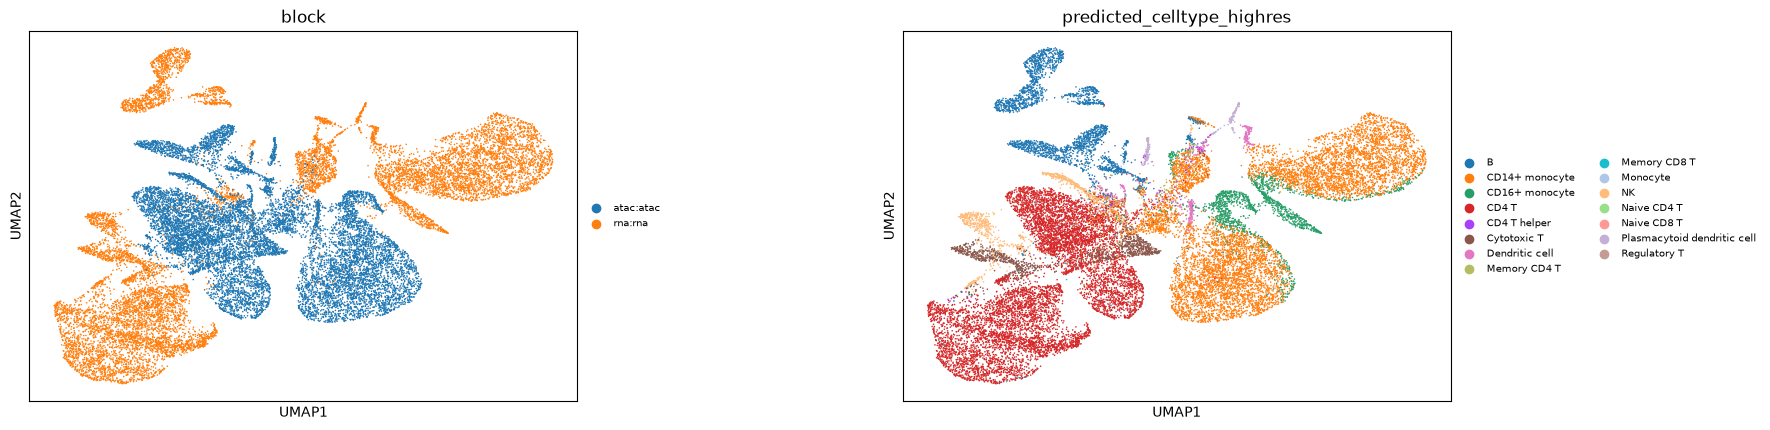

In [18]:
# Fig. 5H–I style: Multiome modality-specific embeddings only.
multiome_stack = stack_embeddings(
    model,
    [
        ("rna", "rna", ref["rna"]),
        ("atac", "atac", ref["atac"]),
    ],
    device=device,
)

# stack_embeddings concatenates blocks in the supplied order.
multiome_stack.obs[MULTIOME_HIGHRES_PRED] = pd.Categorical(
    np.concatenate(
        [highres_pred, highres_pred]
    ),
    categories=highres_classes,
)

sc.pp.neighbors(
    multiome_stack,
    use_rep="X_univi",
    n_neighbors=30,
)
sc.tl.umap(
    multiome_stack,
    random_state=0,
)
sc.pl.umap(
    multiome_stack,
    color=[
        "block",
        MULTIOME_HIGHRES_PRED,
    ],
    wspace=0.45,
    legend_fontsize=7,
)

## Marker validation on Multiome RNA (Fig. 5J; Supp. Fig. S5)

The biological validation is performed on **Multiome RNA**, grouped by the transferred higher-resolution predictions.

The first plot shows predictions and confidence on the fused paired Multiome latent. The second overlays representative RNA markers on the same fused UMAP. The final dot plot summarizes a broader marker panel by predicted group.

C:\Users\ashfo\AppData\Local\Temp\ipykernel_17748\3140148316.py:47: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(multiome_marker,target_sum=1e4,)


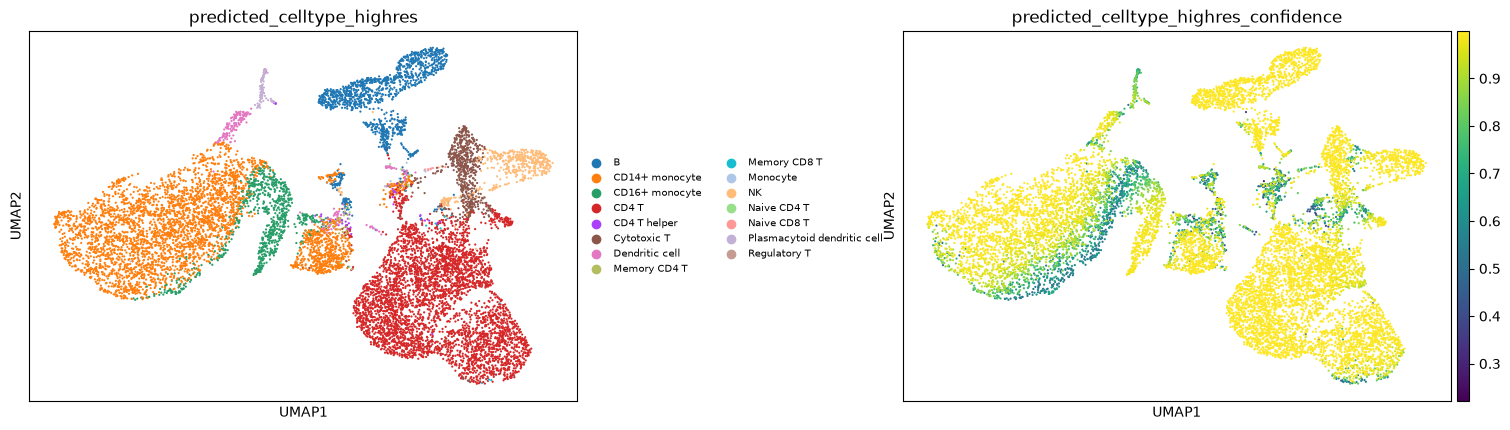

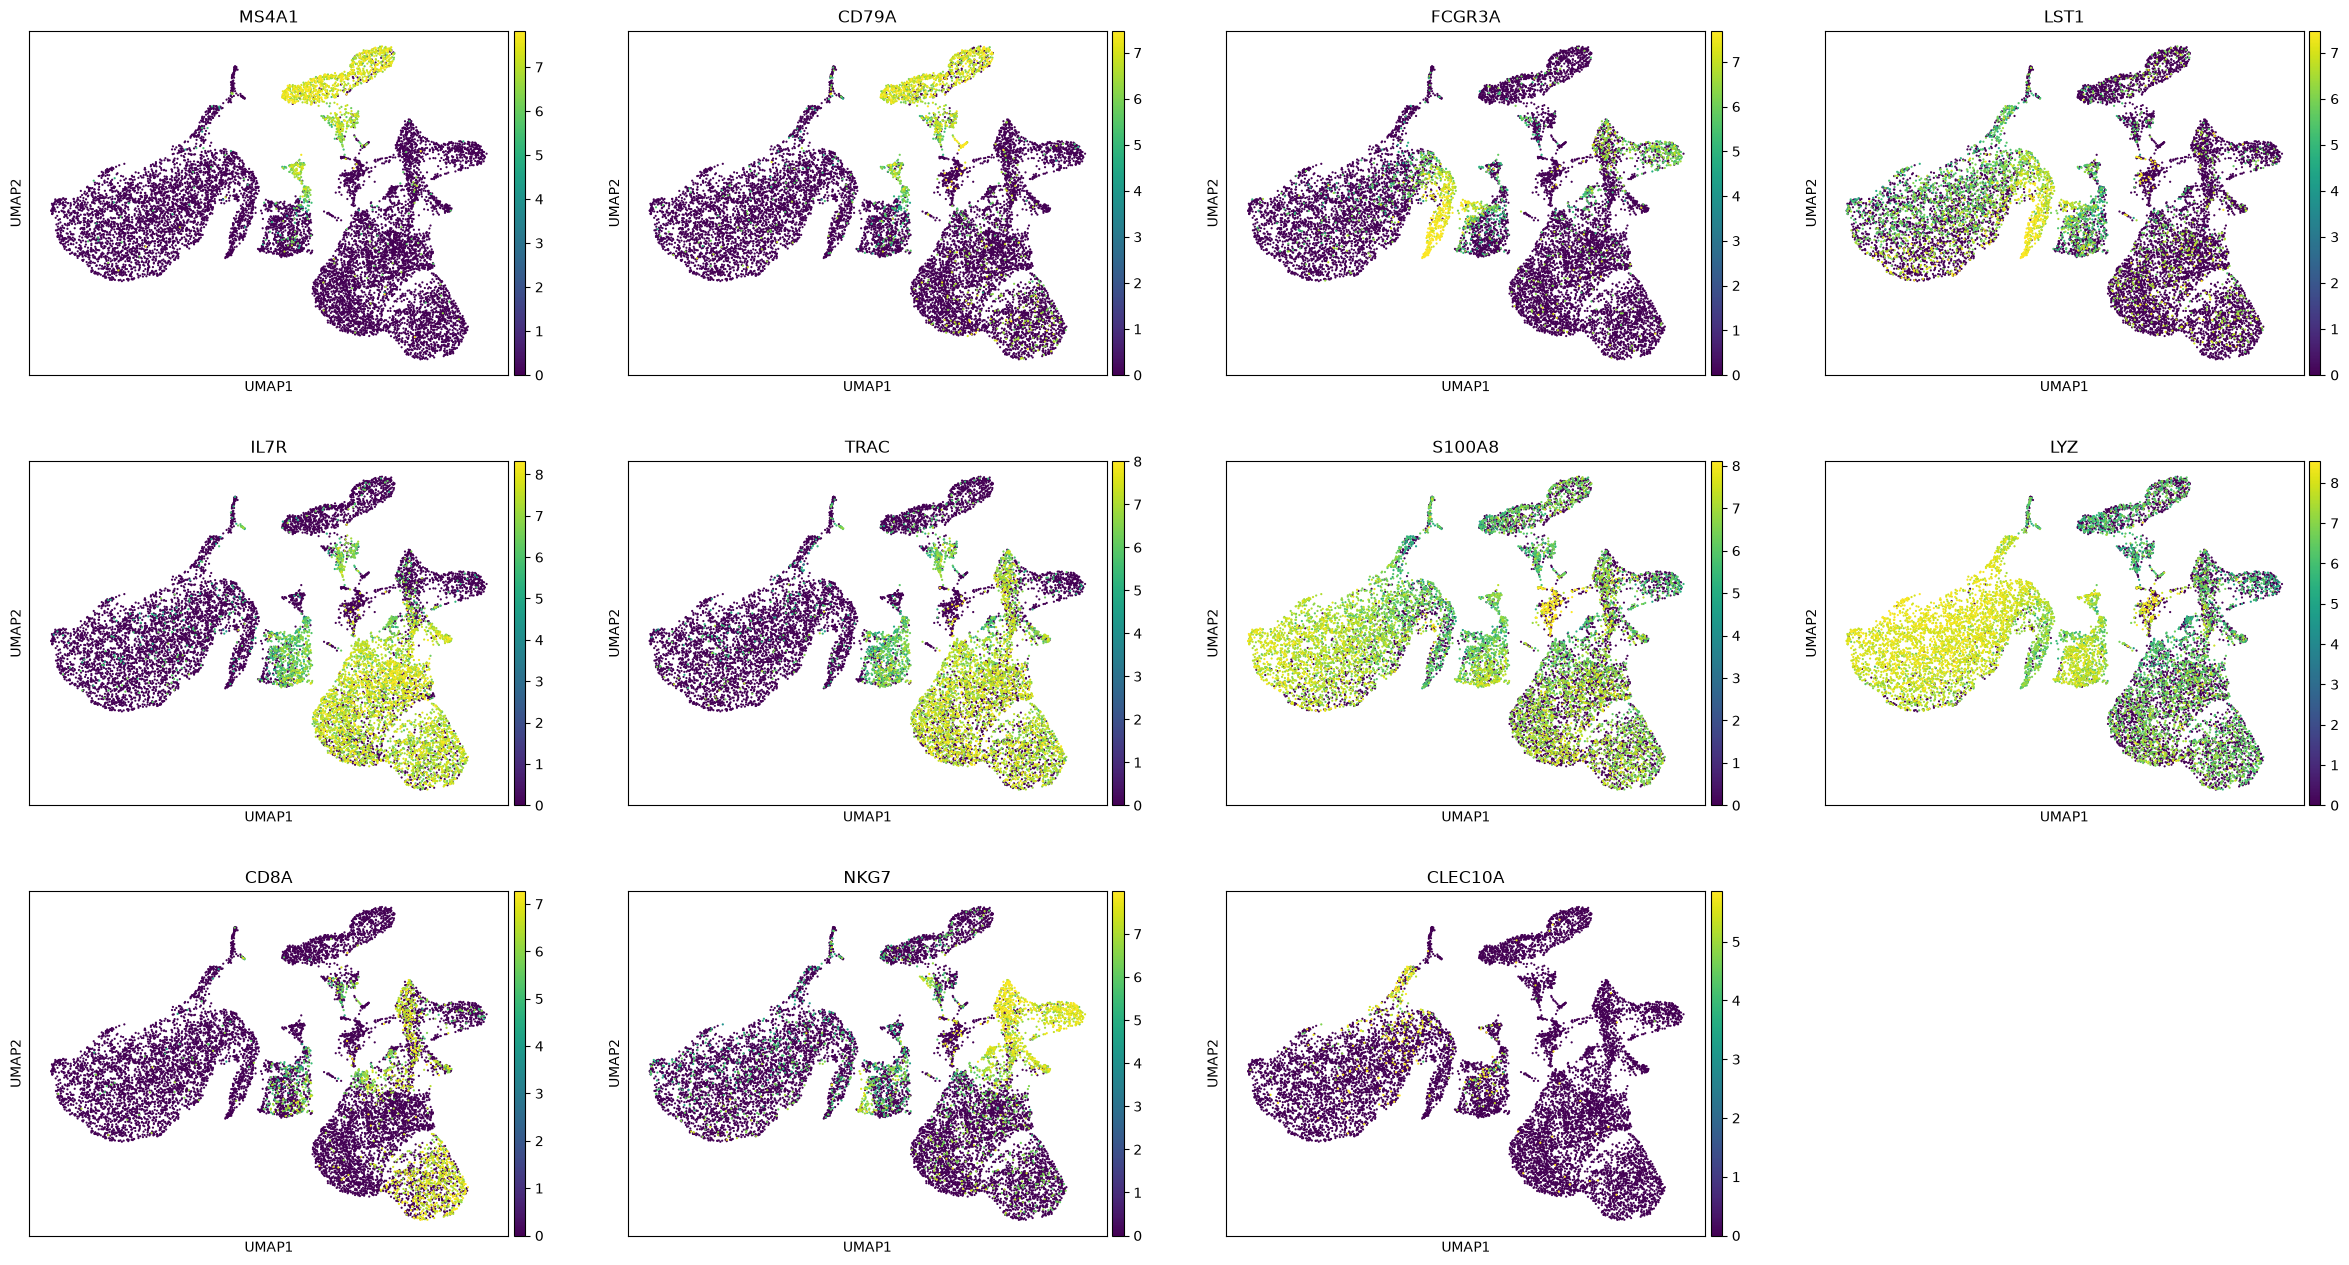

In [19]:
# One fused point per paired Multiome cell (MoE mean).
z_multiome_fused = encode_fused_adata_pair(
    model,
    adata_by_mod=ref,
    device=device,
    write_to_adatas=False,
)["mu"]

marker_panel = [
    "MS4A1",
    "CD79A",
    "CD74",
    "CD19",
    "CD27",
    "IL7R",
    "CCR7",
    "LTB",
    "TRAC",
    "TRBC1",
    "CD247",
    "CD8A",
    "CD8B",
    "GNLY",
    "NKG7",
    "FGFBP2",
    "FCGR3A",
    "LST1",
    "S100A8",
    "S100A9",
    "FCN1",
    "LYZ",
    "FCER1A",
    "CLEC10A",
    "GZMB",
    "IRF7",
]

available_markers = [gene for gene in marker_panel if gene in rna.var_names]
multiome_marker = rna[:, available_markers,].copy()

# Prefer raw counts if the hosted object carries them.
if "counts" in multiome_marker.layers:
    multiome_marker.X = (
        multiome_marker.layers["counts"].copy()
    )

sc.pp.normalize_total(multiome_marker,target_sum=1e4,)
sc.pp.log1p(multiome_marker)

multiome_marker.obs[
    MULTIOME_HIGHRES_PRED
] = pd.Categorical(
    highres_pred,
    categories=highres_classes,
)
multiome_marker.obs[
    MULTIOME_HIGHRES_CONF
] = highres_conf

multiome_marker.obsm[
    "X_univi"
] = z_multiome_fused

sc.pp.neighbors(
    multiome_marker,
    use_rep="X_univi",
    n_neighbors=30,
)
sc.tl.umap(
    multiome_marker,
    random_state=0,
)
sc.pl.umap(
    multiome_marker,
    color=[
        MULTIOME_HIGHRES_PRED,
        MULTIOME_HIGHRES_CONF,
    ],
    wspace=0.45,
    legend_fontsize=7,
)

overlay_markers = [
    gene
    for gene in [
        "MS4A1",
        "CD79A",
        "FCGR3A",
        "LST1",
        "IL7R",
        "TRAC",
        "S100A8",
        "LYZ",
        "CD8A",
        "NKG7",
        "CLEC10A",
    ]
    if gene in multiome_marker.var_names
]

sc.pl.umap(
    multiome_marker,
    color=overlay_markers,
    ncols=4,
    vmax="p99",
)

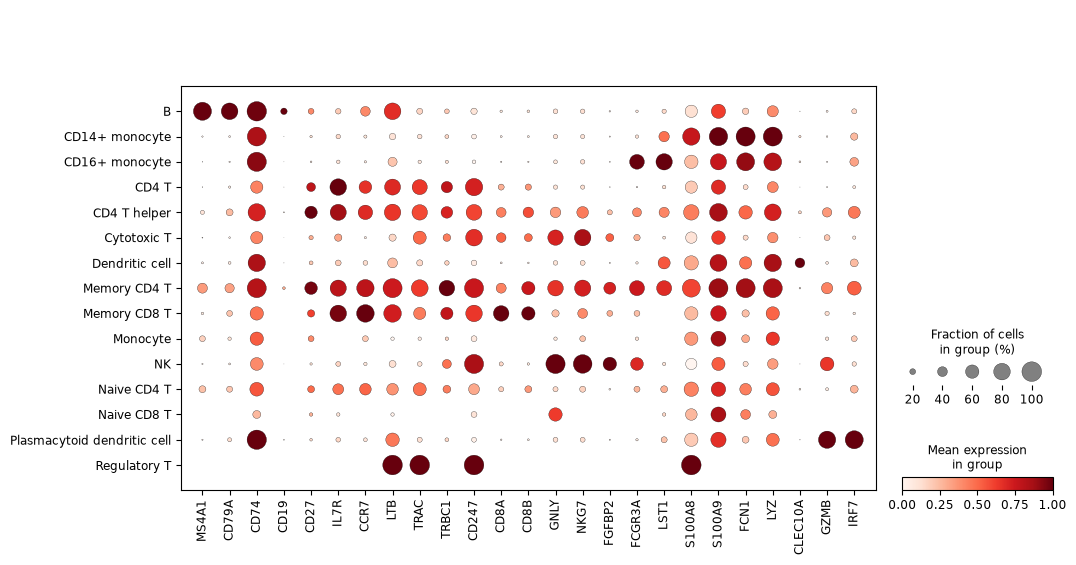

In [20]:
multiome_marker.obs[MULTIOME_HIGHRES_PRED] = multiome_marker.obs[MULTIOME_HIGHRES_PRED].astype("category").cat.remove_unused_categories()
sc.pl.dotplot(
    multiome_marker,
    var_names=available_markers,
    groupby=MULTIOME_HIGHRES_PRED,
    standard_scale="var",
    dendrogram=False,
)